<a href="https://colab.research.google.com/github/NadiiaIvashchuk/DTA_2026/blob/main/ML/LinearRegression_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


У реальній роботі завантажте CSV через `pd.read_csv("file.csv")`.

**Генеруємо дані**  
Створюємо таблицю з ознаками й «справжньою» ціною (з невеликим випадковим шумом, як у житті).

In [3]:
n = 1000  # скільки квартир

area      = np.random.normal(60, 20, n).clip(20, 140)        # площа, м²
rooms     = np.clip(np.round(area / 25 + np.random.normal(0, 0.6, n)), 1, 5)  # кімнати
floor     = np.random.randint(1, 25, n)                      # поверх
dist_km   = np.random.exponential(5, n).clip(0.3, 25)        # відстань до центру, км
age_years = np.random.randint(0, 60, n)                      # вік будинку, років

# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)

df = pd.DataFrame({
    "area": area.round(1),
    "rooms": rooms.astype(int),
    "floor": floor,
    "dist_km": dist_km.round(1),
    "age_years": age_years,
    "price": price.round(1),
})

df.head()

,area,rooms,floor,dist_km,age_years,price
0,69.9,4,6,2.6,14,172.1
1,57.2,3,11,6.4,30,122.8
2,73.0,3,3,2.4,54,146.3
3,90.5,3,8,3.4,13,217.6
4,55.3,3,3,2.8,10,165.2


Виводимо для ознайомлення основні показники датасету - розмір таблиці, чи є na-значення, дублікати, аномалії, типи даних кожного стовпця. Якщо тип даних не відповідає суті характеристики - вивчаємо що не так і приводимо до єдиного типу за стовпцем(якщо за суттю це числове значення, то привести до типу даних int, float), оскільки це впливає на математичні розрахунки. За схожою логікою працюємо з іншими відхиленнями

In [4]:
print(f"Розмір таблиці: {df.shape[0]} rows x {df.shape[1]} columns" )
print(f"\nЧи є пропуски: {df.isna().sum()}")
df.describe().round(2)


Розмір таблиці: 1000 rows x 6 columns

Чи є пропуски: area         0
rooms        0
floor        0
dist_km      0
age_years    0
price        0
dtype: int64


,area,rooms,floor,dist_km,age_years,price
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,60.49,2.48,12.69,4.96,30.39,136.25
std,19.33,0.95,7.00,4.71,17.23,44.99
min,20.00,1.00,1.00,0.30,0.00,20.00
25%,47.08,2.00,6.00,1.50,16.00,104.15
50%,60.50,2.00,13.00,3.60,30.00,136.75
75%,73.00,3.00,19.00,7.00,45.25,165.45
max,137.10,5.00,24.00,25.00,59.00,282.40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area       1000 non-null   float64
 1   rooms      1000 non-null   int64  
 2   floor      1000 non-null   int64  
 3   dist_km    1000 non-null   float64
 4   age_years  1000 non-null   int64  
 5   price      1000 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 47.0 KB


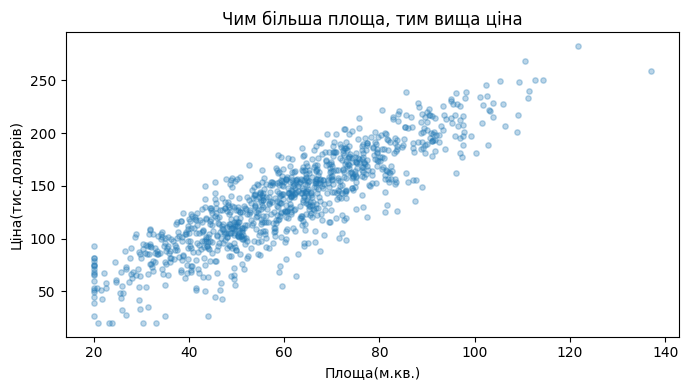

In [6]:
plt.figure(figsize=(7, 4))
plt.scatter(df['area'], df['price'], alpha=0.3, s=15)
plt.xlabel('Площа(м.кв.)')
plt.ylabel("Ціна(тис.доларів)")
plt.title("Чим більша площа, тим вища ціна")
plt.tight_layout()
plt.show()

Розділяємо наші дані:
- спочатку на групу ознак(характеристик) - X, за якими буде навчатись модель, і цільову змінну (параметр, який передбачатиме модель після навчання) - y. Ознак не має бути багато і вони не мають бути "шумом", тобто несуттєвими за впливом на кінцевий результат. Прийнято використовувати X(заглавна) та y
- далі ділимо X та y на навчальну(train) та тестову(test) частини, рандомно у співвідношенні 80% на 20%. Використовуємо  stratify=y як ознаку рівномірного розподілу значень

In [8]:
# Рандомне змішування даних (80% - навчання, 20% - тестування)
from sklearn.model_selection import train_test_split

X = df[['area', 'rooms', 'floor', 'dist_km', 'age_years']] # features ознаки
y = df['price'] # target ціль

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
    #stratify=y
)

print("Навчальна вибірка", X_train.shape[0], "квартир")
print("Тестова вибірка", X_test.shape[0], "квартир")


Навчальна вибірка 800 квартир
Тестова вибірка 200 квартир


- Використовуємо модель LinearRegression (model = LinearRegression() - створення порожньої моделі)
- навчаємо модель (метод fit) на навчальному сеті даних. Після навчання з'являються: model.coef_(коефіцієнти - див.нижче), model.intercept_(базова ціна)
- робимо передбачення на тестовому сеті(X_test)
- робимо порівняння тестового і передбаченого моделлю результату

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train) # fit - we teach model
y_pred = model.predict(X_test)

compare = pd.DataFrame(
    {
        'real_price': y_test[:5].round(2),
        'predict_price': y_pred[:5].round(2)
    }
)
compare ['error'] = (compare['predict_price'] - compare['real_price']).round(2)
compare

,real_price,predict_price,error
521,119.1,129.69,10.59
737,173.3,178.26,4.96
740,20.0,26.36,6.36
660,93.7,110.87,17.17
411,100.6,97.21,-3.39


## Метрики регресії
- MAE - наскільки в середньому ми помилилися - 7 -> 7 тис. $(чим менше - тим краще)
- RMSE(корінь їз MSE) - схожу на MAE, сильніше карає великі промахи (чим менше - тим краще)
- R² - яку частину розкиду (цін) модель може оцінити, пояснити - [0.;1.0]
-> 1 - ідеально, 0 - погано, 0.5 - посередньо

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
#mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE = {mae:.1f} тис.доларів (у середньому помиляємось на стільки)")
#print(f"MSE = {mse:.1f}")
print(f"RMSE = {rmse:.1f} тис.доларів")
print(f"R² = {r2:.3f} (модель пояснює {r2 * 100:.1f}% розкиду ціни)")

MAE = 8.7 тис.доларів (у середньому помиляємось на стільки)
RMSE = 10.8 тис.доларів
R² = 0.947 (модель пояснює 94.7% розкиду ціни)


## Коефіцієнти

- `model.coef_`  - показує вплив кожної ознаки (`+` -> збільшує ціну(target), `-` -> зменшує ціну (target)). Як інтерпритувати - "За інших рівних умов коефіцієнт.."
- `model.intercept_` - базове значення моделі, тобто ціна (target), коли всі ознаки = 0

In [19]:
coefs = pd.DataFrame({
        'features': X.columns,
        'coef': model.coef_.round(2)
}).sort_values('coef', key=abs, ascending=False) # key=abs - | modul |

print(f"Базова ціна: {model.intercept_:.2F} тис.долапів\n")
print("Як кожна ознака впливає на ціну")

coefs

Базова ціна: 40.83 тис.долапів

Як кожна ознака впливає на ціну


,features,coef
1,rooms,5.22
3,dist_km,-3.07
0,area,1.78
4,age_years,-0.49
2,floor,0.39


## Формула, за якою працює наша модель після навчання:
`Базова ціна: 40.83 тис.дол`
`+` `5.22 * rooms` `+` `3.07 * dist_km` `+` `1.78 * area` `+` `0.49 * age_years` `+` `0.39 * floor`

In [17]:
price2 = (
    40.83
    + area * 1.78
    + rooms * 5.22
    + dist_km * (-3.07)
    + age_years	* (-0.49)
    + floor * (0.39)
).round(2)
price2

array([173.55, 128.31, 153.6 , 203.94, 142.61, 122.23, 179.2 , 171.29,
       118.54, 164.14, 126.07, 116.75, 166.34,  62.83,  44.97, 117.7 ,
        92.18, 133.12, 102.4 ,  97.15, 217.31, 131.35, 137.86, 109.43,
       118.57, 126.86,  78.88,  91.06, 102.68, 126.35, 109.23, 198.63,
       162.55,  96.12, 192.27,  99.  , 143.42,  50.62,  99.65, 111.79,
       155.5 , 136.37, 105.08, 124.62,  21.76, 118.34, 139.87, 154.63,
       164.06,  69.76, 106.17,  99.29,  95.93, 131.75, 159.97, 195.5 ,
        97.81, 141.04, 139.33, 167.79, 105.81, 105.43, 100.14,  95.62,
       143.79, 194.33, 151.21, 179.08, 153.59, 109.1 , 139.67, 201.75,
       128.77, 199.6 ,  66.77, 165.55, 141.3 , 138.  , 154.94,  69.78,
       126.59, 166.01, 195.3 , 105.12, 109.6 ,  72.58, 192.65, 165.3 ,
        68.96, 164.44, 112.82, 178.88, 113.4 , 127.24, 124.76,  66.26,
       132.74, 147.47, 132.28, 134.96,  88.39,  72.3 , 122.01,  81.39,
       104.78, 141.85, 199.4 , 150.47, 162.19, 153.03,  58.51, 157.51,
      

# USE model to new flat

In [13]:
new_flat = pd.DataFrame([{
    "area": 110.3,
    "rooms": 3,
    "floor": 9,
    "dist_km": 1.7,
    "age_years": 6
}])

new_flat

,area,rooms,floor,dist_km,age_years
0,110.3,3,9,1.7,6


In [18]:
print(f"Дана квартира вартуватиме: {model.predict(new_flat)[0]:.1f} тис.дол. +- {mae:.1f} тис.дол.")


Дана квартира вартуватиме: 248.6 тис.дол. +- 8.7 тис.дол.
